In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
save_dir = '/media/manatee/TestData/WFFFB/'

In [3]:
metadata = np.load(save_dir+'frame_metadata.npy', allow_pickle=True).item()
num_frames = metadata['num_frames']
frame_width = metadata['frame_width']
frame_height = metadata['frame_height']
data_type = metadata['data_type']
frame_timestamps = metadata['frame_timestamps']
sys_timestamps = metadata['sys_clock_timestamps']

In [4]:
print(num_frames, len(frame_timestamps))

1007 1007


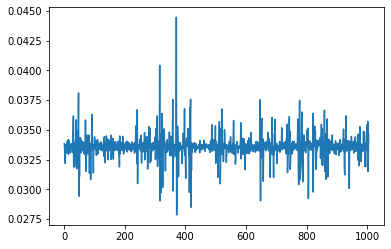

In [5]:
plt.plot(np.diff(sys_timestamps)[:])

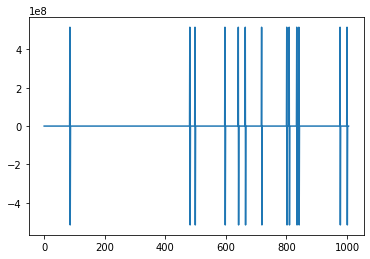

In [6]:
plt.figure()
plt.plot(np.diff(frame_timestamps)[:])

In [7]:
exposure = np.median(np.diff(frame_timestamps))
print(exposure)

336.0


In [8]:
((frame_timestamps[-1]-frame_timestamps[0])/10000)*(1/(exposure/10000))

1005.3303571428571

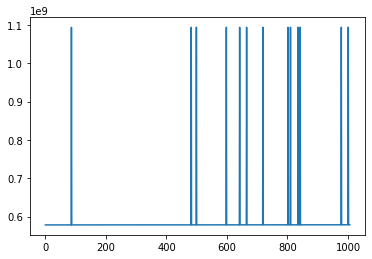

In [9]:
plt.figure()
plt.plot(frame_timestamps)

In [10]:
frames = []
with open(save_dir+'video_frames.bin', 'rb') as f:
    for _ in range(num_frames):
        # Read the size of the next frame
        frame_size = int.from_bytes(f.read(4), 'little')
        # Read the frame data
        frame_data = f.read(frame_size)
        frame = np.frombuffer(frame_data, dtype=data_type)
        frame = frame.reshape((frame_height, frame_width, 1))  # Assuming RGB frames
        frames.append(frame)


In [13]:
frames = np.array(frames)
frames = frames.reshape((num_frames, frame_height//8, 8, frame_height//8, 8))
frames = frames.sum(axis=(2, 4), dtype=np.uint16)

In [14]:
unique_vals = np.unique(frames[:10])

In [15]:
unique_vals

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 27, 28, 29, 30], dtype=uint8)

In [16]:
unique_vals.shape

(23,)

In [19]:
baseline = frames.mean(axis=0)
dff0 = (frames[:100]-baseline)/baseline

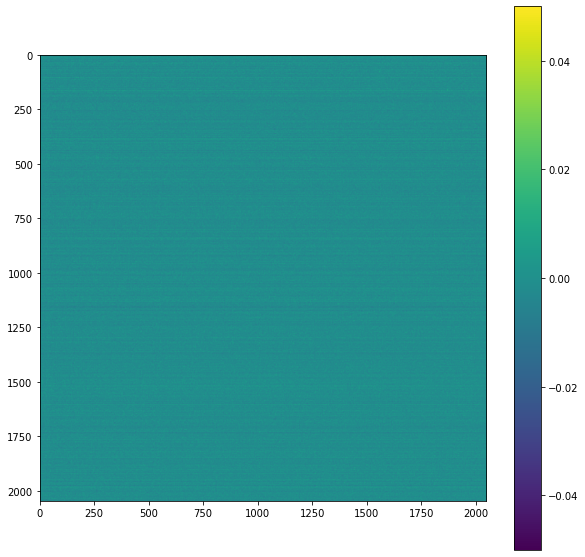

In [23]:
plt.figure(figsize=(10, 10))
plt.imshow(dff0.mean(axis=0), cmap='viridis', vmin=-0.05, vmax=0.05)
plt.colorbar()

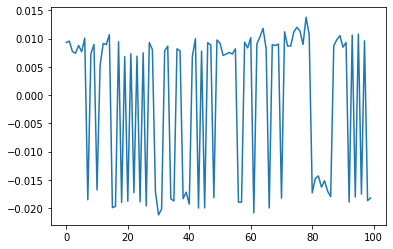

In [24]:
plt.figure()
plt.plot(dff0.mean(axis=1).mean(axis=1))

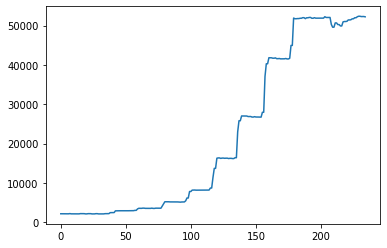

In [25]:
plt.figure()
plt.plot(frames.mean(axis=1).mean(axis=1))

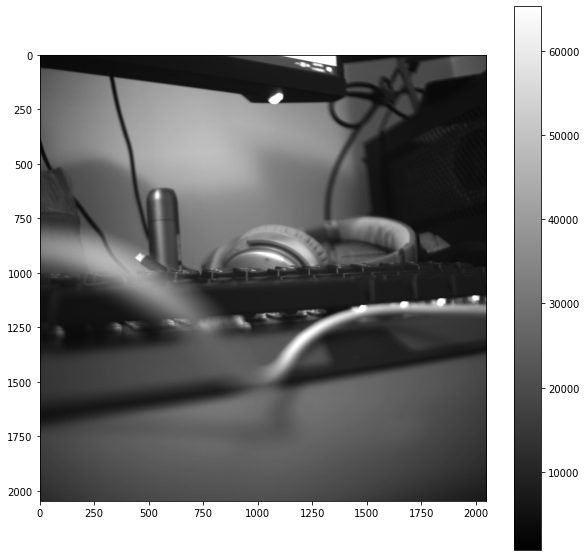

In [67]:
plt.figure(figsize=(10,10))
plt.imshow(frames[2], cmap='gray')
plt.colorbar()

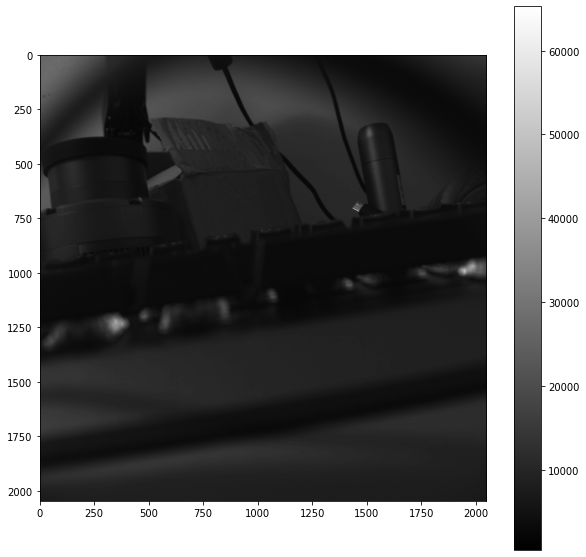

In [59]:
plt.figure(figsize=(10,10))
plt.imshow(frames[8], cmap='gray')
plt.colorbar()

In [11]:
len(frames)

218